# Simulasi Shor's Algorithm
## Perbandingan Exact QFT vs Approximate QFT
**Reproduksi: Sun, Zhang, Franchetti — CMU HPEC 2023**

---
**Inti Perbandingan:**

| | Exact QFT | Approximate QFT (jurnal) |
|---|---|---|
| Gate CP | Semua dipakai — O(n²) | Dibuang jika sudut < threshold — O(n·log n) |
| Implementasi | `QFT(inverse=True)` bawaan Qiskit | Manual dari **Listing 1 jurnal** |
| Tujuan | Baseline akurasi | Lebih cepat, akurasi tidak jauh turun |

> **Platform:** BRIN HPC Trembesi — CPU Only (`AerSimulator`, no GPU)

***1. Import Library***

In [1]:
import numpy as np
import math
import random
import time
from fractions import Fraction

import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit_aer import AerSimulator

***2. Set Parameter N dan Basis a***

In [2]:
# ── Pilih N sesuai partition Trembesi ─────────────────────────────
# interactive  (2 jam)  → N ≤ 35
# short        (1 hari) → N ≤ 111
# medium-small (3 hari) → N ≤ 323

N = 35

# Pilih basis a secara acak yang coprime dengan N
candidates = [a for a in range(2, N-1) if math.gcd(a, N) == 1]
a = random.choice(candidates)

n       = math.ceil(math.log2(N))   # ukuran work register
n_count = 2 * n                      # ukuran phase register

print(f"N              = {N}")
print(f"a              = {a}")
print(f"Phase register = {n_count} qubit")
print(f"Work register  = {n} qubit")
print(f"Total qubit    = {n_count + n}")

N              = 35
a              = 27
Phase register = 12 qubit
Work register  = 6 qubit
Total qubit    = 18


***3. Fungsi Perkalian Modular***

In [3]:
def modular_multiplication(a, N, n):
    size = 2 ** n
    perm = np.zeros(size, dtype=int)

    for y in range(size):
        if y < N:
            perm[y] = (a * y) % N
        else:
            perm[y] = y

    U_perm = np.zeros((size, size), dtype=complex)
    for y in range(size):
        U_perm[perm[y], y] = 1.0

    return UnitaryGate(U_perm)

***4. Approximate QFT — Implementasi Manual dari Listing 1 Jurnal***

Ini adalah **kontribusi utama jurnal** (Section IV, halaman 2).

```python
# Listing 1 jurnal (persis):
while i >= 0:
    circuit.h(up_reg[i])
    j = i - 1
    while j >= 0 and (i - j) <= kmax:   # ← threshold kmax
        circuit.cp(π / 2^(i-j), ...)
        j -= 1
    i -= 1
```

Gate `CP(π/2^k)` **dilewati** jika `k > kmax`.  
`kmax = floor(log₂ n_count)` dipilih secara empiris di jurnal.

In [4]:
def approximate_qft(circuit, register, n, kmax):
    """
    Approximate QFT — implementasi langsung dari Listing 1 jurnal.

    Perbedaan dari Exact QFT:
    Gate CP(π/2^k) DILEWATI jika (i-j) > kmax.
    Ini mengurangi gate dari O(n²) → O(n·kmax).

    Sesuai: Beauregard (2002), Coppersmith (2002).
    """
    i = n - 1
    while i >= 0:
        circuit.h(register[i])
        j = i - 1
        while j >= 0 and (i - j) <= kmax:   # ← KUNCI: threshold kmax
            angle = np.pi / (2 ** (i - j))
            circuit.cp(angle, register[i], register[j])
            j -= 1
        i -= 1

    # Bit-reversal swap
    for k in range(n // 2):
        circuit.swap(register[k], register[n - 1 - k])


# Pilih kmax sesuai jurnal: floor(log2(n_count))
kmax = math.floor(math.log2(n_count))
print(f"kmax = floor(log2({n_count})) = {kmax}")

kmax = floor(log2(12)) = 3


***5. Bangun Sirkuit — Exact QFT dan Approximate QFT***

In [5]:
# ── Sirkuit 1: EXACT QFT ──────────────────────────────────────────
# Menggunakan QFT bawaan Qiskit persis seperti file asli
qc_exact = QuantumCircuit(n_count + n, n_count)

phase = list(range(n_count))
work  = list(range(n_count, n_count + n))

for q in range(n_count):
    qc_exact.h(phase[q])
qc_exact.barrier()

qc_exact.x(work[0])
qc_exact.barrier()

for q in range(n_count):
    exponent   = pow(a, 2**q, N)
    U          = modular_multiplication(exponent, N, n)
    controlled = U.control()
    qc_exact.append(controlled, [phase[q]] + work)
qc_exact.barrier()

# ← Exact QFT bawaan Qiskit (semua gate CP dipakai)
qc_exact.append(QFT(n_count, inverse=True), phase)
qc_exact.barrier()
qc_exact.measure(phase, range(n_count))

print(f"Exact QFT   — Depth: {qc_exact.depth()}, "
      f"Gate CP: {qc_exact.decompose().count_ops().get('cp', '—')}")

Exact QFT   — Depth: 16, Gate CP: —


/tmp/ipykernel_595711/370636253.py:23: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_exact.append(QFT(n_count, inverse=True), phase)


In [6]:
# ── Sirkuit 2: APPROXIMATE QFT (Listing 1 jurnal) ─────────────────
qc_approx = QuantumCircuit(n_count + n, n_count)

for q in range(n_count):
    qc_approx.h(phase[q])
qc_approx.barrier()

qc_approx.x(work[0])
qc_approx.barrier()

for q in range(n_count):
    exponent   = pow(a, 2**q, N)
    U          = modular_multiplication(exponent, N, n)
    controlled = U.control()
    qc_approx.append(controlled, [phase[q]] + work)
qc_approx.barrier()

# ← Approximate QFT manual dari Listing 1 jurnal
# Buat register untuk approximate_qft
from qiskit.circuit import QuantumRegister
phase_reg = list(range(n_count))
approximate_qft(qc_approx, phase_reg, n_count, kmax)
qc_approx.barrier()
qc_approx.measure(phase, range(n_count))

print(f"Approx QFT  — Depth: {qc_approx.depth()}, "
      f"kmax: {kmax}")

Approx QFT  — Depth: 39, kmax: 3


***6. Validasi Sirkuit***

In [7]:
print(f"Depth Exact  : {qc_exact.depth()}")
print(f"Depth Approx : {qc_approx.depth()}")

Depth Exact  : 16
Depth Approx : 39


***7. Simulasi dengan Qiskit Aer CPU***

In [8]:
SHOTS = 8192
sim   = AerSimulator()

# ── Jalankan Exact QFT ────────────────────────────────────────────
print("Menjalankan Exact QFT...", end=" ", flush=True)
t0           = time.time()
compiled_e   = transpile(qc_exact, sim, optimization_level=3)
result_e     = sim.run(compiled_e, shots=SHOTS).result()
t_exact      = time.time() - t0
counts_exact = result_e.get_counts()
print(f"selesai ({t_exact:.2f}s)")

# ── Jalankan Approximate QFT ──────────────────────────────────────
print("Menjalankan Approximate QFT...", end=" ", flush=True)
t1             = time.time()
compiled_a     = transpile(qc_approx, sim, optimization_level=3)
result_a       = sim.run(compiled_a, shots=SHOTS).result()
t_approx       = time.time() - t1
counts_approx  = result_a.get_counts()
print(f"selesai ({t_approx:.2f}s)")

Menjalankan Exact QFT... selesai (2.90s)
Menjalankan Approximate QFT... selesai (2.87s)


***8. Post-Processing — Temukan Faktor***

In [9]:
def find_factors(counts, n_count, N, a):
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

    for state, _ in sorted_counts[:15]:
        state_clean = state.replace(' ', '')[:n_count]
        if state_clean == '0' * n_count:
            continue

        decimal = int(state_clean, 2)
        phase_v = decimal / (2 ** n_count)
        frac    = Fraction(phase_v).limit_denominator(N)
        r       = frac.denominator

        if r == 0 or r % 2 != 0:
            continue

        p = math.gcd(pow(a, r//2) - 1, N)
        q = math.gcd(pow(a, r//2) + 1, N)

        if p not in (1, N) and N % p == 0:
            return r, p, N // p
        if q not in (1, N) and N % q == 0:
            return r, q, N // q

    return None, None, None


r_e, p_e, q_e = find_factors(counts_exact,  n_count, N, a)
r_a, p_a, q_a = find_factors(counts_approx, n_count, N, a)

print(f"Exact  QFT → r={r_e}, faktor: {p_e} × {q_e}")
print(f"Approx QFT → r={r_a}, faktor: {p_a} × {q_a}")

Exact  QFT → r=4, faktor: 7 × 5
Approx QFT → r=4, faktor: 7 × 5


***9. Correctness Analysis — Reproduksi Tabel II Jurnal***

$$C_E = \frac{\text{shots exact berhasil}}{\text{total shots}} \times 100\%$$

$$C_A = \frac{\text{shots approx berhasil}}{\text{total shots}} \times 100\%$$

$$\text{Rel. Diff} = \frac{|C_E - C_A|}{C_E} \times 100\%$$

$$\text{Speedup} = \frac{t_{\text{exact}}}{t_{\text{approx}}}$$

In [10]:
def hitung_correctness(counts, n_count, N, a, shots):
    success = 0
    Q       = 2 ** n_count

    for state, cnt in counts.items():
        dec = int(state.replace(' ', '')[:n_count], 2)
        if dec == 0:
            continue
        frac = Fraction(dec / Q).limit_denominator(N)
        r    = frac.denominator
        if r == 0 or r % 2 != 0:
            continue
        p = math.gcd(pow(a, r//2) - 1, N)
        q = math.gcd(pow(a, r//2) + 1, N)
        if p not in (1, N) or q not in (1, N):
            success += cnt

    return round(success / shots * 100, 2)


CE      = hitung_correctness(counts_exact,  n_count, N, a, SHOTS)
CA      = hitung_correctness(counts_approx, n_count, N, a, SHOTS)
rel     = round(abs(CE - CA) / CE * 100, 2) if CE > 0 else 0
speedup = round(t_exact / t_approx, 2) if t_approx > 0 else 0

# Gate CP — hitung dari sirkuit approx secara manual
# Exact: n*(n-1)/2 gate CP (semua pasang qubit)
# Approx: hanya kmax gate per qubit
cp_exact  = n_count * (n_count - 1) // 2
cp_approx = sum(min(kmax, i) for i in range(n_count))
reduksi   = round((1 - cp_approx / cp_exact) * 100, 1) if cp_exact > 0 else 0

print("=" * 56)
print("  TABEL PERBANDINGAN — Sesuai Tabel II Jurnal")
print("=" * 56)
print(f"  N = {N}, a = {a}, kmax = {kmax}, Shots = {SHOTS}")
print()
print(f"  {'':25} {'Exact':>10} {'Approx':>10}")
print(f"  {'-'*47}")
print(f"  {'Correctness (%)':25} {CE:>10.2f} {CA:>10.2f}")
print(f"  {'Relative Diff (%)':25} {'—':>10} {rel:>10.2f}")
print(f"  {'Speedup (x)':25} {'—':>10} {speedup:>10.2f}")
print(f"  {'Gate CP (est.)':25} {cp_exact:>10} {cp_approx:>10}")
print(f"  {'Reduksi Gate CP (%)':25} {'—':>10} {reduksi:>10.1f}")
print(f"  {'Depth sirkuit':25} {qc_exact.depth():>10} {qc_approx.depth():>10}")
print(f"  {'Waktu simulasi (s)':25} {t_exact:>10.3f} {t_approx:>10.3f}")
print("=" * 56)

print()
if p_e and q_e:
    print(f"  Exact  → ✅ {N} = {p_e} × {q_e}")
else:
    print(f"  Exact  → ❌ Faktor tidak ditemukan (coba ulang)")
if p_a and q_a:
    print(f"  Approx → ✅ {N} = {p_a} × {q_a}")
else:
    print(f"  Approx → ❌ Faktor tidak ditemukan (coba ulang)")

  TABEL PERBANDINGAN — Sesuai Tabel II Jurnal
  N = 35, a = 27, kmax = 3, Shots = 8192

                                 Exact     Approx
  -----------------------------------------------
  Correctness (%)                74.95      75.35
  Relative Diff (%)                  —       0.53
  Speedup (x)                        —       1.01
  Gate CP (est.)                    66         30
  Reduksi Gate CP (%)                —       54.5
  Depth sirkuit                     16         39
  Waktu simulasi (s)             2.901      2.867

  Exact  → ✅ 35 = 7 × 5
  Approx → ✅ 35 = 7 × 5


***10. Probability Spectrum — Reproduksi Fig. 3 Jurnal***

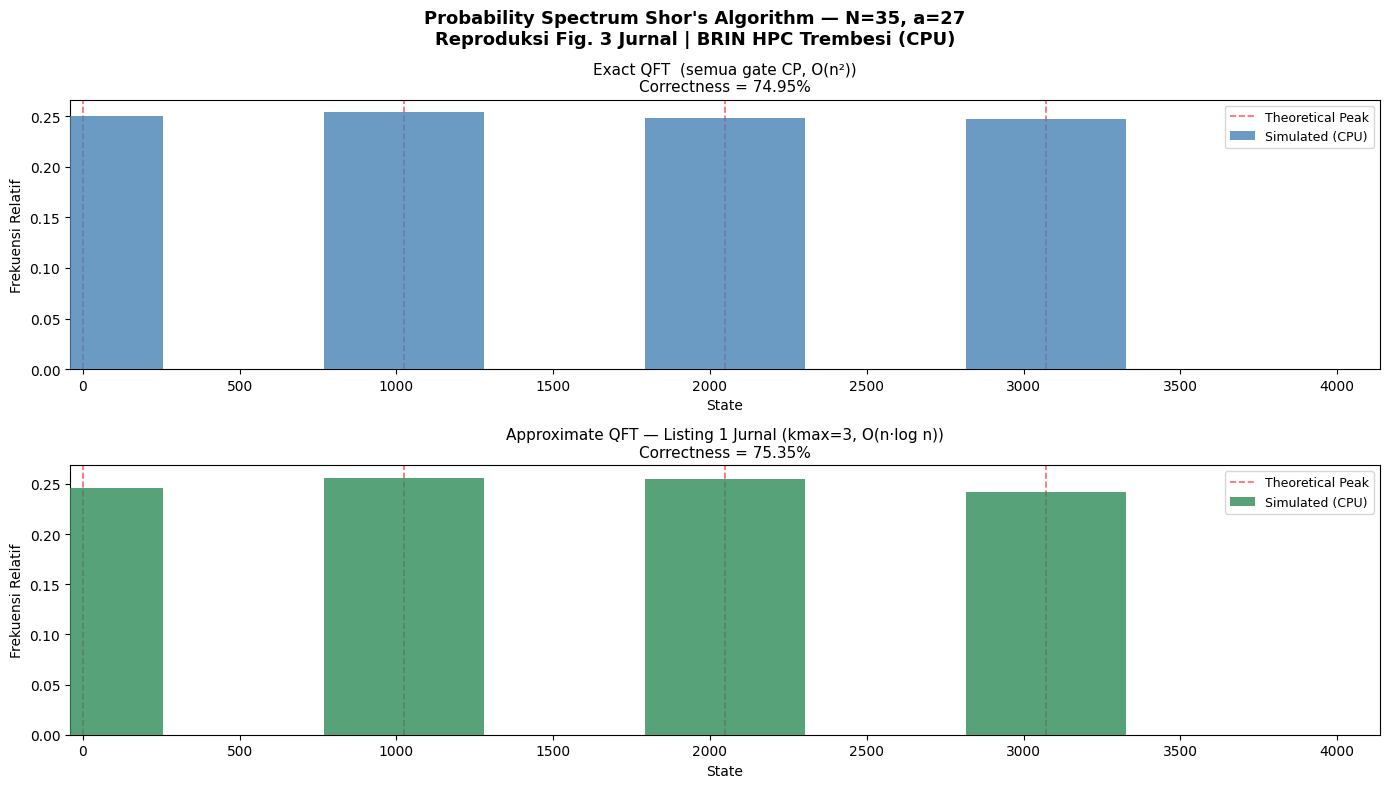

Gambar disimpan: shor_N35_a27.png


In [11]:
Q = 2 ** n_count

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(
    f"Probability Spectrum Shor's Algorithm — N={N}, a={a}\n"
    f"Reproduksi Fig. 3 Jurnal | BRIN HPC Trembesi (CPU)",
    fontsize=13, fontweight='bold'
)

for ax, counts_plot, r_plot, label, ce, color in [
    (axes[0], counts_exact,  r_e,
     f'Exact QFT  (semua gate CP, O(n²))', CE, 'steelblue'),
    (axes[1], counts_approx, r_a,
     f'Approximate QFT — Listing 1 Jurnal (kmax={kmax}, O(n·log n))', CA, 'seagreen'),
]:
    # Konversi ke desimal
    decimal_counts = {}
    for state, cnt in counts_plot.items():
        dec = int(state.replace(' ', '')[:n_count], 2)
        decimal_counts[dec] = decimal_counts.get(dec, 0) + cnt

    total  = sum(decimal_counts.values())
    x_vals = sorted(decimal_counts.keys())
    y_vals = [decimal_counts[x] / total for x in x_vals]

    # Puncak teoritis (garis merah)
    if r_plot:
        theo_peaks = [round(k * Q / r_plot) % Q for k in range(r_plot)]
        for i, p in enumerate(theo_peaks):
            ax.axvline(p, color='red', linestyle='--',
                       alpha=0.6, linewidth=1.2,
                       label='Theoretical Peak' if i == 0 else '')

    # Bar distribusi simulasi
    bar_w = max(Q // max(len(x_vals), 1) // 2, 5)
    ax.bar(x_vals, y_vals, width=bar_w,
           color=color, alpha=0.8,
           label='Simulated (CPU)', zorder=3)

    ax.set_title(
        f"{label}\n"
        f"Correctness = {ce:.2f}%",
        fontsize=11
    )
    ax.set_xlabel('State', fontsize=10)
    ax.set_ylabel('Frekuensi Relatif', fontsize=10)
    ax.set_xlim(-Q * 0.01, Q * 1.01)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'shor_N{N}_a{a}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gambar disimpan: shor_N{N}_a{a}.png")

***11. Visualisasi Pengurangan Gate CP***

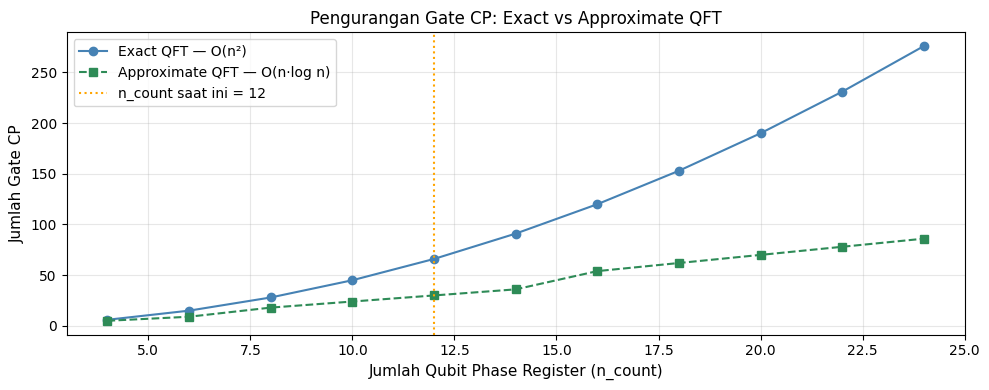

Gambar disimpan: gate_reduction.png


In [12]:
# Perbandingan jumlah gate CP: Exact vs Approximate
# untuk berbagai ukuran n_count

ns    = list(range(4, n_count * 2 + 2, 2))
exact = [n * (n-1) // 2 for n in ns]
kmax_list = [math.floor(math.log2(n)) if n > 1 else 1 for n in ns]
approx = [sum(min(km, i) for i in range(n))
          for n, km in zip(ns, kmax_list)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ns, exact,  'o-', color='steelblue', label='Exact QFT — O(n²)')
ax.plot(ns, approx, 's--', color='seagreen', label='Approximate QFT — O(n·log n)')

# Tandai posisi n_count saat ini
ax.axvline(n_count, color='orange', linestyle=':', linewidth=1.5,
           label=f'n_count saat ini = {n_count}')

ax.set_xlabel('Jumlah Qubit Phase Register (n_count)', fontsize=11)
ax.set_ylabel('Jumlah Gate CP', fontsize=11)
ax.set_title('Pengurangan Gate CP: Exact vs Approximate QFT', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gate_reduction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan: gate_reduction.png")

***12. Info Node***

In [13]:
import socket, sys, os
print(f"Hostname   : {socket.gethostname()}")
print(f"Python     : {sys.version.split()[0]}")
print(f"Executable : {sys.executable}")
print(f"CPU cores  : {os.cpu_count()}")

Hostname   : trembesi32
Python     : 3.10.19
Executable : /mgpfs/home/mkhairiansyah/.conda/envs/env-ml/bin/python
CPU cores  : 128
